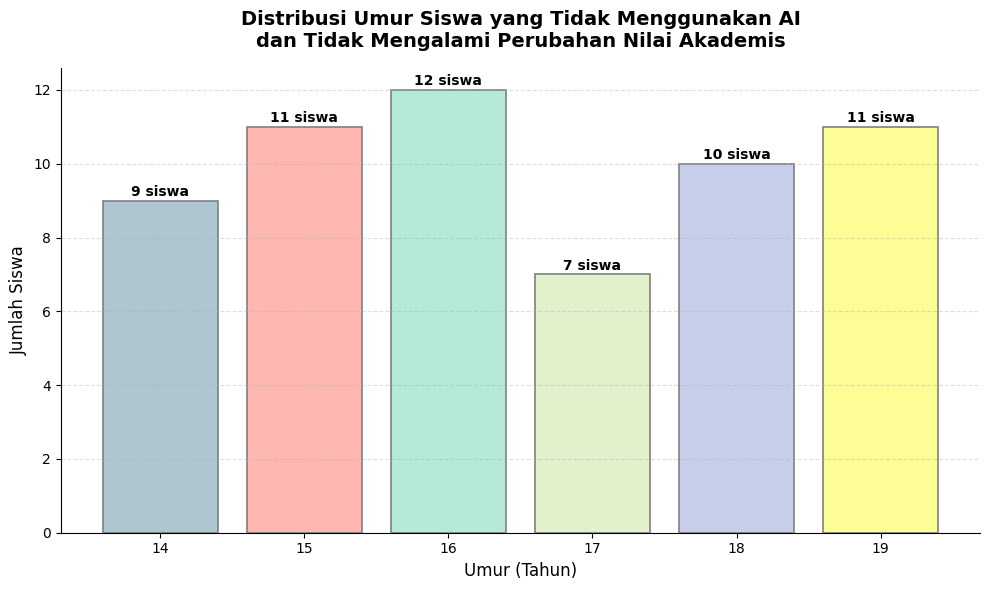

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
file_path = 'Kelas F_Student AI Usage.csv'
df = pd.read_csv(file_path)

# 2. Filter: siswa yang TIDAK menggunakan AI dan nilai tidak berubah
filtered_df = df[
    (df['uses_ai'] == 'No') &
    (df['grades_before_ai'] == df['grades_after_ai'])
].reset_index(drop=True)

# 3. Hitung jumlah siswa per umur
data_grafik = filtered_df['age'].value_counts().sort_index().reset_index()
data_grafik.columns = ['age', 'jumlah_siswa']

# 4. Warna pastel
colors = [
    '#AEC6CF',  # pastel blue
    '#FFB7B2',  # pastel pink
    '#B5EAD7',  # mint
    '#E2F0CB',  # sage
    '#C7CEEA',  # lavender
    '#FDFD96',  # soft yellow
    '#FFDAB9',  # peach
    '#E6E6FA'   # lilac
]

# Jika jumlah umur lebih banyak dari jumlah warna
bar_colors = [colors[i % len(colors)] for i in range(len(data_grafik))]

# 5. Membuat Bar Chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    data_grafik['age'],
    data_grafik['jumlah_siswa'],
    color=bar_colors,
    edgecolor='gray',
    linewidth=1.2
)

# 6. Menambahkan label pada setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.05,
        f'{int(yval)} siswa',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# 7. Melengkapi grafik
plt.title(
    'Distribusi Umur Siswa yang Tidak Menggunakan AI\n'
    'dan Tidak Mengalami Perubahan Nilai Akademis',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel('Umur (Tahun)', fontsize=12)
plt.ylabel('Jumlah Siswa', fontsize=12)

plt.xticks(data_grafik['age'])
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Menghilangkan garis atas dan kanan agar lebih modern
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()